# Learning Linear Regression by Inventing Gradient Descent

**Philosophy:** You won't be taught — you will *discover*. Every step builds on the last. Trust the process.

---

## What you'll need

```python
import numpy as np
import matplotlib.pyplot as plt
```

Run the cell below to get started.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---

# PART 1: Finding the Bottom of a Valley

## Exercise 1.1 — Look Before You Leap

Consider this function:

$$f(x) = x^4 - 4x + 10$$

Your first job is simply to **see** it.

Use the plotting helper below to draw the function over the range $x \in [-3, 3]$.

```python
# PLOTTING HELPER — run this cell as-is, you'll use plot_function() throughout the notebook
def plot_function(f, x_range=(-3, 3), num_points=500, title="f(x)", mark_x=None):
    """
    Plots a function f over x_range.
    Optionally marks a specific x value with a red dot.

    Parameters:
        f        : a Python function that takes a number and returns a number
        x_range  : tuple (x_min, x_max)
        title    : string label for the plot
        mark_x   : if provided, draws a red dot at (mark_x, f(mark_x))
    """
    xs = np.linspace(x_range[0], x_range[1], num_points)
    ys = [f(x) for x in xs]
    plt.figure(figsize=(8, 4))
    plt.plot(xs, ys, 'b-', linewidth=2)
    if mark_x is not None:
        plt.plot(mark_x, f(mark_x), 'ro', markersize=10, label=f'x={mark_x:.4f}, f(x)={f(mark_x):.4f}')
        plt.legend()
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid(True)
    plt.show()
```

**Tasks:**

1. Run the plotting helper cell to define `plot_function`.
2. Define $f(x) = x^4 - 4x + 10$ as a Python function.
3. Call `plot_function(f, x_range=(-3, 3), title="x^4 - 4x + 10")`.
4. Visually estimate: **where does the minimum appear to be?** Write your guess as a comment.

In [2]:
# PLOTTING HELPER — run this cell as-is
def plot_function(f, x_range=(-3, 3), num_points=500, title="f(x)", mark_x=None):
    xs = np.linspace(x_range[0], x_range[1], num_points)
    ys = [f(x) for x in xs]
    plt.figure(figsize=(8, 4))
    plt.plot(xs, ys, 'b-', linewidth=2)
    if mark_x is not None:
        plt.plot(mark_x, f(mark_x), 'ro', markersize=10, label=f'x={mark_x:.4f}, f(x)={f(mark_x):.4f}')
        plt.legend()
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid(True)
    plt.show()

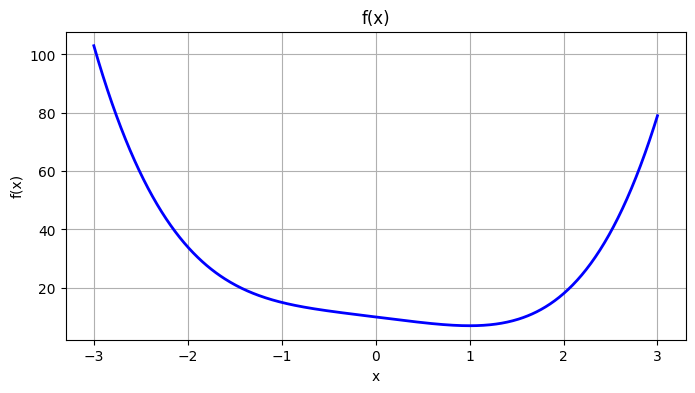

In [ ]:
# YOUR CODE HERE
# Step 1: Define f(x) = x^4 - 4x + 10
def f(x):
    return x**4 - 4*x + 10

# Step 2: Plot it
plot_function(f)

# Step 3: Write your visual estimate of the minimum below
# My guess: x ≈ ???

## Exercise 1.2 — Hit and Trial

Now let's find the minimum by hand — no calculus, just trying values.

The plotting helper accepts a `mark_x` argument. Use it to mark your guesses on the plot.

**Tasks:**

1. Start with your visual estimate from Exercise 1.1. Call `plot_function(f, mark_x=YOUR_GUESS)`.
2. Look at the plot. Is the marked point at the bottom? If not, which direction should you move?
3. Try a new value. Re-plot.
4. Repeat until you are confident you have found the minimum to **2 decimal places**.
5. Record **every guess you made and the function value at that guess** in a table (use a Python list of tuples).

```python
# Template for recording your guesses:
guesses = [
    # (x_value, f(x_value))
    (1.0, f(1.0)),
]
```

**Reflection questions (answer in a markdown cell below):**
- How many guesses did it take?
- What strategy did you use to decide the next guess?
- Can you describe your strategy in plain English, like a recipe?

In [ ]:
# YOUR CODE HERE — try different values of mark_x
plot_function(f, mark_x=1.0, title="My guess: x=1.0")

In [ ]:
# Record all your guesses here
guesses = [
    # (x_value, f(x_value))
]

# Print them nicely
print(f"{'Guess #':<10} {'x':<15} {'f(x)':<15}")
print("-" * 40)
for i, (x, fx) in enumerate(guesses):
    print(f"{i+1:<10} {x:<15.6f} {fx:<15.6f}")

**Your reflection here:**

- How many guesses did it take?
- What was your strategy?
- (Write in plain English)

---

# PART 2: Making the Machine Do the Searching

## Exercise 2.1 — The Slope Tells You Which Way to Walk

You had a strategy when doing hit-and-trial. Let's make it precise.

Think about this: when you are standing on the curve at some point $x$, the **slope** of the curve tells you:
- If slope is **positive** → the function is going *up* to the right → you should move *left* (decrease $x$)
- If slope is **negative** → the function is going *up* to the left → you should move *right* (increase $x$)
- If slope is **zero** → you are at the bottom!

We can approximate the slope (derivative) at any point using:

$$\text{slope at } x \approx \frac{f(x + h) - f(x - h)}{2h} \quad \text{for a very small } h$$

or

$$\text{slope at } x \approx \frac{f(x + h) - f(x)}{h} \quad \text{for a very small } h$$
This is called the **numerical derivative**.

**Tasks:**

1. Write a function `numerical_derivative(f, x, h=1e-5)` that computes the slope at point `x`.
2. Test it on $f(x) = x^4 - 4x + 10$ at a few points: $x = 0, 1, 1.5, 2$.
3. Print both the slope value and whether it's positive, negative, or near-zero.
4. Manually verify one of your answers: the true derivative is $f'(x) = 4x^3 - 4$. Does your numerical result match?

In [6]:
# YOUR CODE HERE
def numerical_derivative(f, x, h=1e-5):
    """
    Returns the approximate derivative of f at point x.
    """
    pass  # replace this


# Test it
test_points = [0, 1, 1.5, 2]
for x in test_points:
    slope = numerical_derivative(f, x)
    # print x, slope, and direction

In [8]:
f(1), f(1.000001), f(.99999)

(7, 7.0000000000060005, 7.0000000005999965)

## Exercise 2.2 — One Step at a Time

Now let's build the update rule.

If you are at position $x$, and the slope there is $s$, your next position should be:

$$x_{\text{new}} = x - \alpha \cdot s$$

where $\alpha$ (alpha) is called the **learning rate** — it controls how big a step you take.

**Tasks:**

1. Start at $x_0 = 2.0$.
2. Compute the slope at $x_0$.
3. Compute $x_1 = x_0 - \alpha \cdot \text{slope}$ with $\alpha = 0.01$.
4. Print $x_0$, slope, and $x_1$.
5. Is $f(x_1) < f(x_0)$? It should be! Why?
6. Now do this **manually** for 5 steps. Print each step. Is $x$ getting closer to the minimum you found in Exercise 1.2?

In [ ]:
# YOUR CODE HERE
alpha = 0.01
x = 2.0

print(f"{'Step':<8} {'x':<15} {'f(x)':<15} {'slope':<15}")
print("-" * 55)

for step in range(5):
    slope = numerical_derivative(f, x)
    print(f"{step:<8} {x:<15.6f} {f(x):<15.6f} {slope:<15.6f}")
    x = x - alpha * slope  # the update rule

## Exercise 2.3 — Build `find_minima_1d`

Now automate the process. Write a function that keeps taking steps until the slope is close enough to zero.

**Stopping condition:** Stop when $|\text{slope}| < \epsilon$ (a small tolerance, e.g. $10^{-6}$), or when you've taken `max_steps` steps.

```python
def find_minima_1d(f, x_start, alpha=0.01, epsilon=1e-6, max_steps=10000):
    """
    Finds the x that minimizes f using gradient descent.

    Parameters:
        f         : function to minimize
        x_start   : starting point
        alpha     : learning rate
        epsilon   : stop when |slope| < epsilon
        max_steps : maximum number of steps

    Returns:
        x_min     : the x value at the minimum
        f_min     : the function value at the minimum
        history   : list of (step, x, f(x)) tuples
    """
    pass  # YOUR IMPLEMENTATION
```

**Tasks:**

1. Implement `find_minima_1d`.
2. Test it on $f(x) = x^4 - 4x + 10$ starting from $x = 2.0$.
3. Print the final answer and how many steps it took.
4. Does it match your manual answer from Exercise 1.2?

In [ ]:
# YOUR CODE HERE
def find_minima_1d(f, x_start, alpha=0.01, epsilon=1e-6, max_steps=10000):
    pass


# Test it
x_min, f_min, history = find_minima_1d(f, x_start=2.0)
print(f"Minimum found at x = {x_min:.6f}")
print(f"f(x_min) = {f_min:.6f}")
print(f"Steps taken: {len(history)}")

## Exercise 2.4 — Watch It Learn

Use the plotting helper below to visualize the descent path. Run it after you have `history` from Exercise 2.3.

```python
# PLOTTING HELPER — descent path
def plot_descent(f, history, x_range=(-3, 3), title="Gradient Descent"):
    """
    Plots the function and shows how x evolved during descent.
    history: list of (step, x, f(x)) tuples
    """
    xs = np.linspace(x_range[0], x_range[1], 500)
    ys = [f(x) for x in xs]

    steps, xvals, fvals = zip(*history)

    plt.figure(figsize=(12, 4))

    # Left: function with descent path
    plt.subplot(1, 2, 1)
    plt.plot(xs, ys, 'b-', linewidth=2, label='f(x)')
    plt.plot(xvals, fvals, 'ro-', markersize=3, alpha=0.5, label='descent path')
    plt.plot(xvals[-1], fvals[-1], 'g*', markersize=15, label=f'minimum: x={xvals[-1]:.4f}')
    plt.title(title)
    plt.xlabel('x'); plt.ylabel('f(x)'); plt.legend(); plt.grid(True)

    # Right: f(x) over steps
    plt.subplot(1, 2, 2)
    plt.plot(steps, fvals, 'b-')
    plt.title('f(x) value over steps')
    plt.xlabel('step'); plt.ylabel('f(x)'); plt.grid(True)

    plt.tight_layout()
    plt.show()
```

**Tasks:**

1. Define and run `plot_descent` with your history.
2. What do you observe in the right plot? Is it always decreasing?
3. Try starting from $x = -2.0$ instead. Does it converge to the same minimum? Why or why not?
4. Try `alpha = 0.1`. What happens? Try `alpha = 1.0`. What happens? **Record your observations.**

In [ ]:
# PLOTTING HELPER — run this cell as-is
def plot_descent(f, history, x_range=(-3, 3), title="Gradient Descent"):
    xs = np.linspace(x_range[0], x_range[1], 500)
    ys = [f(x) for x in xs]
    steps, xvals, fvals = zip(*history)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(xs, ys, 'b-', linewidth=2, label='f(x)')
    plt.plot(xvals, fvals, 'ro-', markersize=3, alpha=0.5, label='descent path')
    plt.plot(xvals[-1], fvals[-1], 'g*', markersize=15, label=f'minimum: x={xvals[-1]:.4f}')
    plt.title(title); plt.xlabel('x'); plt.ylabel('f(x)'); plt.legend(); plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(steps, fvals, 'b-')
    plt.title('f(x) over steps'); plt.xlabel('step'); plt.ylabel('f(x)'); plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# YOUR CODE HERE
# Experiment 1: Default settings
x_min, f_min, history = find_minima_1d(f, x_start=2.0)
plot_descent(f, history)

# Experiment 2: Different starting point
# ...

# Experiment 3: Different learning rates
# ...

**Your observations (fill in):**

- Starting from x = -2.0: ...
- With alpha = 0.1: ...
- With alpha = 1.0: ...

---

# PART 3: Stress-Testing Your Algorithm

## Exercise 3.1 — New Functions, Same Algorithm

Your `find_minima_1d` is general — it should work on any function. Let's test it.

**For each function below:**
1. Define it in Python.
2. Plot it to visually estimate the minimum.
3. Run `find_minima_1d` and record the result.
4. Plot the descent path.
5. Note any problems or surprises.

**Functions to test:**

| # | Function | x_range to plot | Suggested x_start |
|---|----------|-----------------|-------------------|
| A | $f(x) = x^6 - 4x^2 + 10$ | $(-2, 2)$ | $1.5$ |
| B | $f(x) = (x - 3)^2 + 5$ | $(0, 6)$ | $0.0$ |
| C | $f(x) = x^2 + 3\|x\|$ | $(-4, 4)$ | $2.0$ |
| D | $f(x) = e^x - 5x$ | $(0, 4)$ | $3.0$ |
| E | $f(x) = x^4 - 3x^3 + 2$ | $(-1, 3)$ | $2.5$ |

> **Caution on Function A:** Plot it first. Does it have one minimum or more? What does that mean for your algorithm?

In [ ]:
# Function A
def fA(x):
    return x**6 - 4*x**2 + 10

plot_function(fA, x_range=(-2, 2), title="fA: x^6 - 4x^2 + 10")

# YOUR CODE: run find_minima_1d and plot_descent
# What do you notice? Are there multiple minima?

In [ ]:
# Function B — YOUR CODE
def fB(x):
    pass

# plot, find_minima_1d, plot_descent

In [ ]:
# Function C — YOUR CODE
def fC(x):
    pass

# plot, find_minima_1d, plot_descent

In [ ]:
# Function D — YOUR CODE
def fD(x):
    pass

# plot, find_minima_1d, plot_descent

In [ ]:
# Function E — YOUR CODE
def fE(x):
    pass

# plot, find_minima_1d, plot_descent

## Exercise 3.2 — Function A Is Sneaky

Plot Function A carefully. You should notice it has **two local minima** — one on the left and one on the right.

**Tasks:**

1. Run `find_minima_1d` on Function A starting from $x = 1.5$. Where does it end up?
2. Run it starting from $x = -1.5$. Where does it end up?
3. Run it starting from $x = 0.0$. Where does it end up?
4. Which of the two minima is the **global** minimum (lowest overall)? Which is just a **local** minimum?
5. Can your algorithm always find the global minimum? What would you need to do to be more confident?

Write your answers in a markdown cell.

In [ ]:
# YOUR CODE HERE
for x_start in [1.5, -1.5, 0.0]:
    x_min, f_min, history = find_minima_1d(fA, x_start=x_start, alpha=0.01)
    print(f"Start: x={x_start:.1f}  →  Minimum at x={x_min:.6f}, f(x)={f_min:.6f}")

**Your analysis:**

- Global minimum: ...
- Local minimum: ...
- Can the algorithm always find the global minimum? ...

---

# PART 4: Two Variables — A Landscape Instead of a Curve

## Exercise 4.1 — See the Landscape

Now consider a function of **two variables**:

$$g(x, y) = x^2 + y^2$$

This is a bowl shape in 3D. The minimum is clearly at $(x, y) = (0, 0)$.

Use the 2D plotting helper below to visualize it.

```python
# PLOTTING HELPER — 2D contour plot
def plot_function_2d(f2, x_range=(-3, 3), y_range=(-3, 3), num_points=100, title="f(x,y)", mark_xy=None):
    """
    Plots a 2-variable function as a contour map.

    Parameters:
        f2       : function that takes (x, y) and returns a scalar
        x_range  : (x_min, x_max)
        y_range  : (y_min, y_max)
        mark_xy  : if provided as (x, y), draws a red dot at that point
    """
    xs = np.linspace(x_range[0], x_range[1], num_points)
    ys = np.linspace(y_range[0], y_range[1], num_points)
    X, Y = np.meshgrid(xs, ys)
    Z = np.array([[f2(x, y) for x in xs] for y in ys])

    plt.figure(figsize=(6, 5))
    contour = plt.contourf(X, Y, Z, levels=30, cmap='viridis')
    plt.colorbar(contour)
    if mark_xy is not None:
        plt.plot(mark_xy[0], mark_xy[1], 'r*', markersize=15,
                 label=f'({mark_xy[0]:.3f}, {mark_xy[1]:.3f})')
        plt.legend()
    plt.title(title)
    plt.xlabel('x'); plt.ylabel('y')
    plt.show()
```

**Tasks:**

1. Define and run the `plot_function_2d` helper.
2. Define $g(x, y) = x^2 + y^2$ and plot it.
3. What color represents the minimum? What color represents high values?
4. Now plot these functions and describe the shape of each landscape:
   - $h_1(x, y) = (x - 1)^2 + (y + 2)^2$
   - $h_2(x, y) = x^2 + 4y^2$
   - $h_3(x, y) = x^2 + y^2 + x*y$
5. Visually identify the minimum of each.

In [ ]:
# PLOTTING HELPER — run this cell as-is
def plot_function_2d(f2, x_range=(-3, 3), y_range=(-3, 3), num_points=100, title="f(x,y)", mark_xy=None):
    xs = np.linspace(x_range[0], x_range[1], num_points)
    ys = np.linspace(y_range[0], y_range[1], num_points)
    X, Y = np.meshgrid(xs, ys)
    Z = np.array([[f2(x, y) for x in xs] for y in ys])
    plt.figure(figsize=(6, 5))
    contour = plt.contourf(X, Y, Z, levels=30, cmap='viridis')
    plt.colorbar(contour)
    if mark_xy is not None:
        plt.plot(mark_xy[0], mark_xy[1], 'r*', markersize=15,
                 label=f'({mark_xy[0]:.3f}, {mark_xy[1]:.3f})')
        plt.legend()
    plt.title(title); plt.xlabel('x'); plt.ylabel('y')
    plt.show()

In [ ]:
# YOUR CODE HERE
def g(x, y):
    return x**2 + y**2

plot_function_2d(g, title="g(x,y) = x^2 + y^2")

# Now define and plot h1, h2, h3
# ...

## Exercise 4.2 — Partial Derivatives

With two variables, the slope has **two components** — one for each variable.

The **partial derivative** with respect to $x$ tells you the slope if you move only in the $x$ direction (holding $y$ fixed).

We can compute them numerically the same way:

$$\frac{\partial f}{\partial x} \approx \frac{f(x+h, y) - f(x-h, y)}{2h}$$

$$\frac{\partial f}{\partial y} \approx \frac{f(x, y+h) - f(x, y-h)}{2h}$$

or

$$\frac{\partial f}{\partial x} \approx \frac{f(x+h, y) - f(x, y)}{h}$$

$$\frac{\partial f}{\partial y} \approx \frac{f(x, y+h) - f(x, y)}{h}$$


Together, $(\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y})$ is called the **gradient** — it points in the direction of steepest *increase*.

**Tasks:**

1. Write a function `partial_x(f2, x, y, h=1e-5)` that returns $\partial f / \partial x$.
2. Write a function `partial_y(f2, x, y, h=1e-5)` that returns $\partial f / \partial y$.
3. Write a function `gradient_2d(f2, x, y, h=1e-5)` that returns the tuple `(df_dx, df_dy)`.
4. Test on $g(x, y) = x^2 + y^2$ at several points:
   - $(1, 1)$ → expected gradient: $(2, 2)$
   - $(3, 0)$ → expected gradient: $(6, 0)$
   - $(0, 0)$ → expected gradient: $(0, 0)$
5. For $h_2(x, y) = x^2 + 4y^2$, compute the gradient at $(1, 1)$ and $(0, 2)$. Do the answers make intuitive sense? (Which direction does the gradient point — toward or away from the minimum?)

In [ ]:
# YOUR CODE HERE
def partial_x(f2, x, y, h=1e-5):
    pass

def partial_y(f2, x, y, h=1e-5):
    pass

def gradient_2d(f2, x, y, h=1e-5):
    pass


# Test on g(x,y) = x^2 + y^2
test_points = [(1, 1), (3, 0), (0, 0)]
for (x, y) in test_points:
    grad = gradient_2d(g, x, y)
    print(f"Gradient at ({x}, {y}) = {grad}")

## Exercise 4.3 — Build `find_minima_2d`

Now extend the 1D algorithm to 2D. The update rule becomes:

$$x_{\text{new}} = x - \alpha \cdot \frac{\partial f}{\partial x}$$
$$y_{\text{new}} = y - \alpha \cdot \frac{\partial f}{\partial y}$$

Both variables are updated simultaneously.

**Stopping condition:** Stop when $\sqrt{(\partial f/\partial x)^2 + (\partial f/\partial y)^2} < \epsilon$. This is the **magnitude** of the gradient (how steep the hill is overall).

**Tasks:**

1. Implement `find_minima_2d(f2, x_start, y_start, alpha=0.1, epsilon=1e-6, max_steps=10000)`.
   - It should return `(x_min, y_min, f_min, history)` where `history` is a list of `(step, x, y, f(x,y))` tuples.
2. Test it on $g(x, y) = x^2 + y^2$ starting from $(2, 3)$. It should find $(0, 0)$.
3. Test it on $h_1(x, y) = (x-1)^2 + (y+2)^2$ starting from $(3, 3)$. Expected minimum: $(1, -2)$.
4. Test it on $h_2(x, y) = x^2 + 4y^2$ starting from $(2, 2)$. Expected minimum: $(0, 0)$.

Use `plot_function_2d` with `mark_xy=(x_min, y_min)` to verify your answers visually.

In [ ]:
# YOUR CODE HERE
def find_minima_2d(f2, x_start, y_start, alpha=0.1, epsilon=1e-6, max_steps=10000):
    pass


# Test on g
x_min, y_min, f_min, history = find_minima_2d(g, x_start=2.0, y_start=3.0)
print(f"g: minimum at ({x_min:.4f}, {y_min:.4f}), f={f_min:.6f}, steps={len(history)}")
plot_function_2d(g, mark_xy=(x_min, y_min), title="g: descent result")

In [ ]:
# Test on h1
def h1(x, y):
    return (x - 1)**2 + (y + 2)**2

# YOUR CODE: run find_minima_2d and verify


In [ ]:
# Test on h2
def h2(x, y):
    return x**2 + 4*y**2

# YOUR CODE: run find_minima_2d and verify
# Try alpha=0.1. Does it converge? Try alpha=0.3. What happens?

## Exercise 4.4 — Visualize the Path (2D)

Use the helper below to draw the descent path on the contour map.

```python
# PLOTTING HELPER — 2D descent path
def plot_descent_2d(f2, history, x_range=(-4, 4), y_range=(-4, 4), title="2D Gradient Descent"):
    """
    history: list of (step, x, y, f(x,y)) tuples
    """
    xs = np.linspace(x_range[0], x_range[1], 100)
    ys = np.linspace(y_range[0], y_range[1], 100)
    X, Y = np.meshgrid(xs, ys)
    Z = np.array([[f2(x, y) for x in xs] for y in ys])

    steps, xvals, yvals, fvals = zip(*history)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.contourf(X, Y, Z, levels=30, cmap='viridis')
    plt.colorbar()
    plt.plot(xvals, yvals, 'w-o', markersize=3, alpha=0.6, label='path')
    plt.plot(xvals[0], yvals[0], 'rs', markersize=10, label='start')
    plt.plot(xvals[-1], yvals[-1], 'g*', markersize=15, label='end')
    plt.legend(); plt.title(title); plt.xlabel('x'); plt.ylabel('y')

    plt.subplot(1, 2, 2)
    plt.plot(steps, fvals, 'b-')
    plt.title('f(x,y) over steps'); plt.xlabel('step'); plt.ylabel('f(x,y)'); plt.grid(True)

    plt.tight_layout()
    plt.show()
```

**Tasks:**

1. Define and run `plot_descent_2d` for at least two of your test functions.
2. Does the path head straight to the minimum, or does it zigzag? Why?
3. For $h_2(x, y) = x^2 + 4y^2$: try `alpha=0.3` and `alpha=0.5`. Describe what you see. **This is a famous problem in gradient descent called oscillation.**

In [ ]:
# PLOTTING HELPER — run this cell as-is
def plot_descent_2d(f2, history, x_range=(-4, 4), y_range=(-4, 4), title="2D Gradient Descent"):
    xs = np.linspace(x_range[0], x_range[1], 100)
    ys = np.linspace(y_range[0], y_range[1], 100)
    X, Y = np.meshgrid(xs, ys)
    Z = np.array([[f2(x, y) for x in xs] for y in ys])
    steps, xvals, yvals, fvals = zip(*history)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.contourf(X, Y, Z, levels=30, cmap='viridis')
    plt.colorbar()
    plt.plot(xvals, yvals, 'w-o', markersize=3, alpha=0.6, label='path')
    plt.plot(xvals[0], yvals[0], 'rs', markersize=10, label='start')
    plt.plot(xvals[-1], yvals[-1], 'g*', markersize=15, label='end')
    plt.legend(); plt.title(title); plt.xlabel('x'); plt.ylabel('y')
    plt.subplot(1, 2, 2)
    plt.plot(steps, fvals, 'b-')
    plt.title('f(x,y) over steps'); plt.xlabel('step'); plt.ylabel('f(x,y)'); plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# YOUR CODE HERE
# Run descent on h2 with different alphas and visualize

---

# PART 5: Going Generic

## Exercise 5.1 — N Variables

Your 1D and 2D algorithms are very similar. Can you unify them?

Think about it this way:
- In 1D, your position is a single number $x$. The gradient is a single number.
- In 2D, your position is a pair $(x, y)$. The gradient is a pair $(\partial f/\partial x, \partial f/\partial y)$.
- In N dimensions, your position is a **list** of N numbers. The gradient is also a **list** of N numbers.

The update rule is always the same:

$$\text{variables}_{\text{new}} = \text{variables} - \alpha \cdot \text{gradient}$$

where both are lists.

**The signature you are building:**

```python
def find_minima(f, variables, alpha=0.01, epsilon=1e-6, max_steps=100000):
    """
    Finds the values of 'variables' that minimize f.

    Parameters:
        f         : a function that takes a LIST of values and returns a scalar
                    e.g., if variables = [x, y], then f([x, y]) should work
        variables : initial guess, a list of numbers [v1, v2, ..., vN]
        alpha     : learning rate
        epsilon   : stop when gradient magnitude < epsilon
        max_steps : maximum number of steps

    Returns:
        min_vars  : list of variable values at the minimum
        f_min     : function value at the minimum
        history   : list of (step, variables_copy, f_value) tuples
    """
    pass
```

**Key challenge:** Computing the gradient for a list of N variables.

For variable $i$, the partial derivative is:
$$\frac{\partial f}{\partial v_i} \approx \frac{f(v_1, ..., v_i + h, ..., v_N) - f(v_1, ..., v_i - h, ..., v_N)}{2h}$$

You need to perturb one variable at a time.

**Tasks:**

1. First, write a helper `compute_gradient(f, variables, h=1e-5)` that returns the gradient as a list.
2. Then write `find_minima(f, variables, ...)`.
3. Test by re-running your earlier examples, but now with the new interface:
   - 1D: `find_minima(lambda v: v[0]**4 - 4*v[0] + 10, [2.0])`
   - 2D: `find_minima(lambda v: v[0]**2 + v[1]**2, [2.0, 3.0])`

In [ ]:
# YOUR CODE HERE
def compute_gradient(f, variables, h=1e-5):
    """
    Computes numerical gradient of f at 'variables'.
    variables: list of N numbers
    Returns: list of N partial derivatives
    """
    pass


def find_minima(f, variables, alpha=0.01, epsilon=1e-6, max_steps=100000):
    pass


# Test 1D
min_vars, f_min, history = find_minima(lambda v: v[0]**4 - 4*v[0] + 10, [2.0])
print(f"1D minimum: x = {min_vars[0]:.6f}, f = {f_min:.6f}")

# Test 2D
min_vars, f_min, history = find_minima(lambda v: v[0]**2 + v[1]**2, [2.0, 3.0])
print(f"2D minimum: x = {min_vars[0]:.6f}, y = {min_vars[1]:.6f}, f = {f_min:.6f}")

## Exercise 5.2 — Three Variables

Test your generic `find_minima` on 3D functions:

$$p(x, y, z) = (x - 1)^2 + (y - 2)^2 + (z + 3)^2$$

The minimum is obviously at $(1, 2, -3)$.

$$q(x, y, z) = x^2 + 2y^2 + 3z^2 - 4x + 6z$$

For $q$: what is the minimum analytically? (Hint: complete the square for each variable.)

**Tasks:**

1. Define $p$ and $q$ as functions that take a list `[x, y, z]`.
2. Run `find_minima` on both, starting from `[0, 0, 0]`.
3. Verify your answer for $p$ is $(1, 2, -3)$.
4. For $q$: first compute the answer analytically, then verify your algorithm found it.

In [ ]:
# YOUR CODE HERE
def p(v):
    x, y, z = v
    return (x - 1)**2 + (y - 2)**2 + (z + 3)**2

def q(v):
    x, y, z = v
    return x**2 + 2*y**2 + 3*z**2 - 4*x + 6*z

# Run find_minima on p
min_vars, f_min, history = find_minima(p, [0.0, 0.0, 0.0])
print(f"p minimum: {min_vars}, f = {f_min:.6f}")

# Run find_minima on q
# YOUR CODE

# What is the analytical answer for q?

---

# PART 6: The Real Problem — Fitting a Line to Data

## Exercise 6.1 — What Does It Mean to Fit a Line?

Suppose you have a dataset: some $x$ values and corresponding $y$ values. You want to find the **straight line** $\hat{y} = mx + c$ that best fits the data.

But what does "best fit" mean?

For each data point $(x_i, y_i)$, your line predicts $\hat{y}_i = m x_i + c$. The **error** for that point is $y_i - \hat{y}_i$.

**Mean Squared Error (MSE)** is defined as:

$$\text{MSE}(m, c) = \frac{1}{N} \sum_{i=1}^{N} (y_i - (m x_i + c))^2$$

A smaller MSE means the line fits the data better.

**Tasks:**

1. Here is some sample data — run the cell below.
2. Plot the data points using the helper below.
3. Try drawing lines with different $(m, c)$ on the same plot. Which looks like the best fit visually?

In [9]:
# DATA — run this cell as-is
np.random.seed(42)
X_data = np.linspace(0, 10, 30)
y_data = 2.5 * X_data + 4.0 + np.random.randn(30) * 3  # true line: m=2.5, c=4.0 + noise

print(f"Number of data points: {len(X_data)}")
print(f"X range: [{X_data.min():.1f}, {X_data.max():.1f}]")
print(f"y range: [{y_data.min():.1f}, {y_data.max():.1f}]")

Number of data points: 30
X range: [0.0, 10.0]
y range: [4.4, 28.4]


In [10]:
# PLOTTING HELPER — data + line overlay
def plot_data_and_line(X, y, m=None, c=None, title="Data"):
    """
    Plots data points. If m and c are given, also draws the line y = mx + c.
    """
    plt.figure(figsize=(8, 5))
    plt.scatter(X, y, color='blue', label='data', zorder=5)
    if m is not None and c is not None:
        x_line = np.linspace(X.min(), X.max(), 200)
        y_line = m * x_line + c
        plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'y = {m:.2f}x + {c:.2f}')
    plt.legend()
    plt.title(title)
    plt.xlabel('X'); plt.ylabel('y')
    plt.grid(True)
    plt.show()

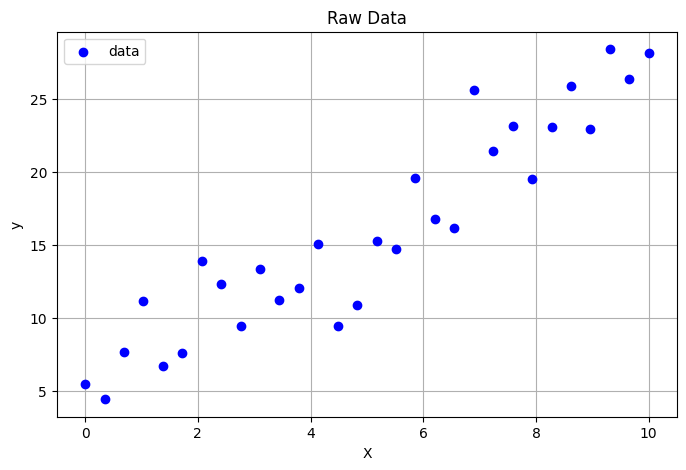

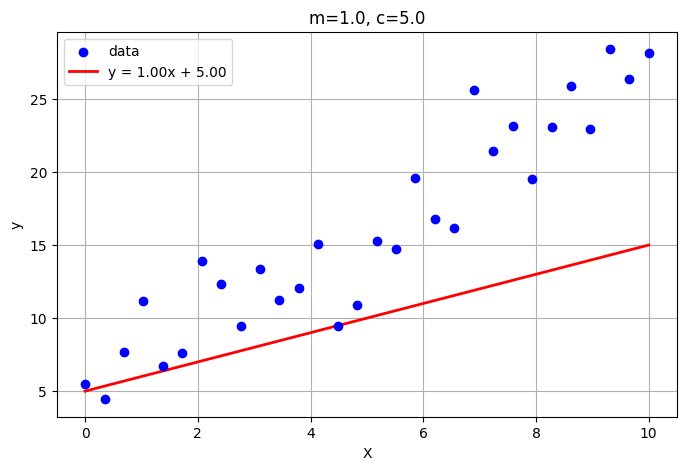

In [11]:
# YOUR CODE HERE
# 1. Plot just the data
plot_data_and_line(X_data, y_data, title="Raw Data")

# 2. Try some lines — which looks best?
plot_data_and_line(X_data, y_data, m=1.0, c=5.0, title="m=1.0, c=5.0")
# try more...

## Exercise 6.2 — Write the MSE Function

Now write a function that quantifies how well a line fits the data.

```python
def mse(X, y, m, c):
    """
    Computes Mean Squared Error for predicting y from X using line y = mx + c.
    
    Parameters:
        X : array of input values (shape: N,)
        y : array of true output values (shape: N,)
        m : slope of the line
        c : intercept of the line

    Returns:
        mse_value : a single number
    """
    pass
```

**Tasks:**

1. Implement `mse`. Do NOT use any library function — write the formula yourself using a loop or numpy operations.
2. Test it:
   - A perfect line should have MSE = 0. Create a tiny dataset where you know the exact answer: `X=[1,2,3]`, `y=[3,5,7]` is perfectly fit by $m=2, c=1$. Verify `mse(X, y, 2, 1) == 0`.
   - For our main dataset, compute MSE for:
     - `m=2.5, c=4.0` (the true line used to generate data)
     - `m=1.0, c=5.0`
     - `m=5.0, c=0.0`
3. Which $(m, c)$ gives the lowest MSE? Does this match your visual judgment from Exercise 6.1?

In [ ]:
# YOUR CODE HERE
def mse(X, y, m, c):
    pass


# Sanity check
X_tiny = np.array([1.0, 2.0, 3.0])
y_tiny = np.array([3.0, 5.0, 7.0])
print(f"MSE for perfect line (should be 0): {mse(X_tiny, y_tiny, 2.0, 1.0):.6f}")

# Compare on main dataset
lines_to_test = [
    (2.5, 4.0, "true line"),
    (1.0, 5.0, "guess 1"),
    (5.0, 0.0, "guess 2"),
]
for m, c, label in lines_to_test:
    error = mse(X_data, y_data, m, c)
    print(f"{label:15s}: m={m}, c={c}  →  MSE={error:.4f}")

## Exercise 6.3 — The MSE Landscape

MSE is a function of $m$ and $c$. Let's visualize it as a 2D landscape.

**Tasks:**

1. Use `plot_function_2d` (from Part 4) to plot MSE over a grid of $(m, c)$ values.
   - Let $m$ range from 0 to 5, and $c$ from -5 to 15.
   - You'll need to wrap `mse` so it takes a form compatible with `plot_function_2d`.
2. What shape does the MSE landscape have? Is it convex? Does it have a clear minimum?
3. Mark the point $(m, c) = (2.5, 4.0)$ on the plot. Is it at or near the minimum?

**Hint for wrapping:**
```python
def mse_landscape(m, c):
    return mse(X_data, y_data, m, c)

plot_function_2d(mse_landscape, x_range=(0, 5), y_range=(-5, 15), title="MSE Landscape (m, c)")
```

In [ ]:
# YOUR CODE HERE
def mse_landscape(m, c):
    return mse(X_data, y_data, m, c)

plot_function_2d(mse_landscape, x_range=(0, 5), y_range=(-5, 15),
                 title="MSE Landscape",
                 mark_xy=(2.5, 4.0))

---

# PART 7: Putting It All Together — Linear Regression via Gradient Descent

## Exercise 7.1 — Minimize MSE with `find_minima`

You now have:
- `find_minima(f, variables)` — a general minimizer
- `mse(X, y, m, c)` — the function to minimize

Put them together.

**The key step:** To use `find_minima`, you need to express MSE as a function of a **list** `[m, c]`:

```python
def mse_for_optimizer(params):
    m, c = params
    return mse(X_data, y_data, m, c)
```

**Tasks:**

1. Define `mse_for_optimizer` as above.
2. Call `find_minima(mse_for_optimizer, [0.0, 0.0])` with an appropriate learning rate.
   - **Warning:** You may need to tune `alpha`. Try `0.001` first, then adjust.
3. Print the final `m` and `c` found by the algorithm.
4. Compare to the true values `m=2.5, c=4.0`. How close did you get?
5. Plot the resulting line over the data using `plot_data_and_line`.

In [ ]:
# YOUR CODE HERE
def mse_for_optimizer(params):
    m, c = params
    return mse(X_data, y_data, m, c)


# Run the optimizer — tune alpha if needed
min_params, f_min, history = find_minima(mse_for_optimizer, [0.0, 0.0], alpha=0.001)

m_found, c_found = min_params
print(f"Found:  m = {m_found:.4f},  c = {c_found:.4f}")
print(f"True:   m = 2.5000,  c = 4.0000")
print(f"MSE at found values: {mse(X_data, y_data, m_found, c_found):.4f}")

# Plot the result
plot_data_and_line(X_data, y_data, m=m_found, c=c_found, title=f"Best fit: m={m_found:.2f}, c={c_found:.2f}")

## Exercise 7.2 — Watch the Line Learn

Let's visualize how the line evolves during gradient descent.

Use the plotting helper below:

```python
# PLOTTING HELPER — animated learning
def plot_learning_progress(X, y, history, steps_to_show=[0, 5, 20, 100, 500, -1]):
    """
    Shows the fitted line at different stages of training.
    history: list of (step, [m, c], mse_value) tuples from find_minima
    """
    n = len(steps_to_show)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

    history_len = len(history)
    x_line = np.linspace(X.min(), X.max(), 100)

    for ax, step_idx in zip(axes, steps_to_show):
        if step_idx == -1:
            step_idx = history_len - 1
        step_idx = min(step_idx, history_len - 1)

        step_num, params, mse_val = history[step_idx]
        m, c = params
        y_line = m * x_line + c

        ax.scatter(X, y, color='blue', s=15, alpha=0.6)
        ax.plot(x_line, y_line, 'r-', linewidth=2)
        ax.set_title(f'Step {step_num}\nm={m:.2f}, c={c:.2f}\nMSE={mse_val:.1f}')
        ax.set_xlabel('X'); ax.set_ylabel('y')
        ax.grid(True)

    plt.tight_layout()
    plt.show()
```

**Tasks:**

1. Run `find_minima` with `alpha=0.001` starting from `[0.0, 0.0]`.
2. Call `plot_learning_progress` with your history.
3. Describe what you see: how does the line change from step 0 to the final step?
4. Also plot the MSE over steps using the 2D descent helper.

> **Note:** For this to work, your `find_minima` history must store `[m, c]` as a list (not just the step index). Make sure your implementation stores a copy of the variables at each step.

In [ ]:
# PLOTTING HELPER — run this cell as-is
def plot_learning_progress(X, y, history, steps_to_show=[0, 5, 20, 100, 500, -1]):
    n = len(steps_to_show)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    history_len = len(history)
    x_line = np.linspace(X.min(), X.max(), 100)
    for ax, step_idx in zip(axes, steps_to_show):
        if step_idx == -1:
            step_idx = history_len - 1
        step_idx = min(step_idx, history_len - 1)
        step_num, params, mse_val = history[step_idx]
        m, c = params
        y_line = m * x_line + c
        ax.scatter(X, y, color='blue', s=15, alpha=0.6)
        ax.plot(x_line, y_line, 'r-', linewidth=2)
        ax.set_title(f'Step {step_num}\nm={m:.2f}, c={c:.2f}\nMSE={mse_val:.1f}')
        ax.set_xlabel('X'); ax.set_ylabel('y'); ax.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# YOUR CODE HERE
min_params, f_min, history = find_minima(mse_for_optimizer, [0.0, 0.0], alpha=0.001)

# Visualize the learning process
plot_learning_progress(X_data, y_data, history, steps_to_show=[0, 5, 20, 100, 500, -1])

## Exercise 7.3 — New Dataset, Same Code

Here are three new datasets. For each:
1. Plot the raw data.
2. Use your `find_minima` + `mse` to find the best-fit line.
3. Plot the fitted line over the data.
4. Report the final $m$, $c$, and MSE.

No new code is needed — you're reusing everything you built.

In [ ]:
# DATASETS — run this cell as-is
np.random.seed(7)

# Dataset 1: negative slope
X1 = np.linspace(0, 10, 40)
y1 = -1.5 * X1 + 20 + np.random.randn(40) * 2

# Dataset 2: steep positive slope
X2 = np.linspace(-5, 5, 50)
y2 = 5.0 * X2 - 10 + np.random.randn(50) * 4

# Dataset 3: nearly flat
X3 = np.linspace(0, 20, 60)
y3 = 0.3 * X3 + 2.0 + np.random.randn(60) * 5

print("Datasets ready: X1/y1, X2/y2, X3/y3")

In [ ]:
# YOUR CODE HERE — Dataset 1
plot_data_and_line(X1, y1, title="Dataset 1 — Raw")

def mse_d1(params):
    m, c = params
    return mse(X1, y1, m, c)

# find_minima and plot result

In [ ]:
# YOUR CODE HERE — Dataset 2


In [ ]:
# YOUR CODE HERE — Dataset 3


## Exercise 7.4 — Sanity Check with NumPy

NumPy has a function `np.polyfit(X, y, 1)` that finds the best-fit line using an exact mathematical formula (not gradient descent).

**Tasks:**

1. Run `np.polyfit(X_data, y_data, 1)` — it returns `[m, c]`.
2. Compare the result to what your gradient descent found.
3. Run the same comparison for all three datasets in Exercise 7.3.
4. Are the answers the same? Should they be exactly the same, or just approximately the same? Why?

**Bonus:** If your answers disagree significantly (more than 0.01), investigate why. Check:
- Did gradient descent converge? (Check the final gradient magnitude.)
- Is your learning rate too large or too small?
- Did you run enough steps?

In [ ]:
# YOUR CODE HERE
m_np, c_np = np.polyfit(X_data, y_data, 1)
print(f"NumPy:          m = {m_np:.4f},  c = {c_np:.4f}")

# Compare with gradient descent result from Exercise 7.1
print(f"Gradient Desc:  m = {m_found:.4f},  c = {c_found:.4f}")

# Repeat for other datasets
# ...

---

# PART 8: Bonus Challenges

If you've made it this far, you've independently discovered **gradient descent** and used it to implement **linear regression**. These are the foundations of almost every machine learning algorithm.

Here are some open-ended challenges to push further:

---

## Challenge A — What if the data isn't linear?

Generate this dataset:

```python
X_quad = np.linspace(-3, 3, 50)
y_quad = 1.5 * X_quad**2 - 2 * X_quad + 1 + np.random.randn(50) * 1.5
```

The data was generated with a **quadratic** function $y = 1.5x^2 - 2x + 1$.

1. Try fitting a straight line to it. What MSE do you get?
2. Now fit a quadratic: $\hat{y} = ax^2 + bx + c$. You now have **3 parameters** to optimize: $[a, b, c]$.
3. Extend your `mse` function to handle any polynomial and minimize it with `find_minima`.
4. Compare the fitted $a, b, c$ to the true values $1.5, -2, 1$.

In [12]:
# Challenge A — YOUR CODE
X_quad = np.linspace(-3, 3, 50)
y_quad = 1.5 * X_quad**2 - 2 * X_quad + 1 + np.random.randn(50) * 1.5

# Step 1: fit a straight line, report MSE
# Step 2: define mse_quadratic(params) where params = [a, b, c]
# Step 3: find_minima(mse_quadratic, [0, 0, 0])

In [16]:
X_quad, y_quad

(array([-3.        , -2.87755102, -2.75510204, -2.63265306, -2.51020408,
        -2.3877551 , -2.26530612, -2.14285714, -2.02040816, -1.89795918,
        -1.7755102 , -1.65306122, -1.53061224, -1.40816327, -1.28571429,
        -1.16326531, -1.04081633, -0.91836735, -0.79591837, -0.67346939,
        -0.55102041, -0.42857143, -0.30612245, -0.18367347, -0.06122449,
         0.06122449,  0.18367347,  0.30612245,  0.42857143,  0.55102041,
         0.67346939,  0.79591837,  0.91836735,  1.04081633,  1.16326531,
         1.28571429,  1.40816327,  1.53061224,  1.65306122,  1.7755102 ,
         1.89795918,  2.02040816,  2.14285714,  2.26530612,  2.3877551 ,
         2.51020408,  2.63265306,  2.75510204,  2.87755102,  3.        ]),
 array([19.59744008, 21.95396913, 17.87583913, 15.07503294, 16.70591233,
        12.49630637, 13.54132538,  9.2339642 ,  9.17161097, 10.49458382,
        10.38737501,  8.66209199,  7.40191283,  6.33905666,  3.83323742,
         4.27654356,  4.01562243,  5.68751591,  4

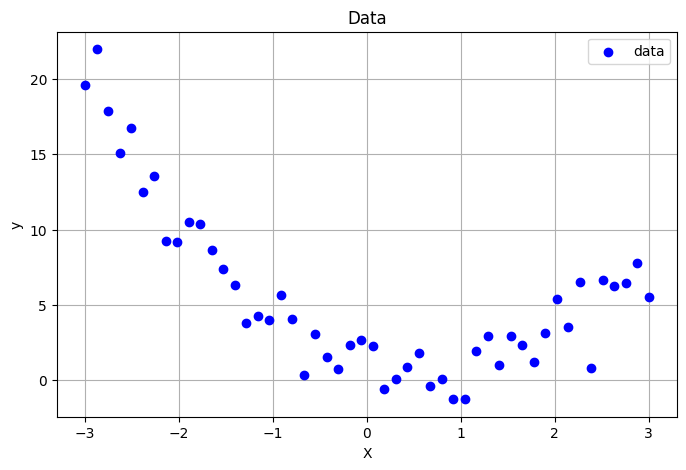

In [14]:
plot_data_and_line(X_quad, y_quad, [-10, 10])

## Challenge B — Learning Rate Scheduler

You've seen that a large $\alpha$ causes oscillation and a small $\alpha$ is slow.

One trick: **decay the learning rate** over time. Start with a large $\alpha$ and make it smaller each step:

$$\alpha_t = \frac{\alpha_0}{1 + t \cdot \text{decay\_rate}}$$

Modify your `find_minima` to support an optional `decay_rate` parameter. Compare:
- Fixed `alpha=0.1` on the MSE problem
- Decaying alpha starting at `0.1` with `decay_rate=0.01`

Which converges faster? Plot both loss curves on the same graph.

In [ ]:
# Challenge B — YOUR CODE

## Challenge C — Stochastic Gradient Descent

In real ML, datasets have millions of points. Computing MSE over all of them every step is expensive.

**Stochastic Gradient Descent (SGD):** Instead of using all data to compute the gradient, use a **random single point** (or a small batch of points) each step.

1. Modify `find_minima` (or write `find_minima_sgd`) to:
   - Each step, pick one random data point $(x_i, y_i)$
   - Compute the gradient of the error for that single point
   - Update $m$ and $c$
2. Run it on `X_data, y_data`.
3. Plot the loss curve. Is it smooth or noisy? Why?
4. How does the final answer compare to full gradient descent?

In [ ]:
# Challenge C — YOUR CODE

---

## Reflection — What Did You Just Build?

Take a moment to answer these questions in your own words:

1. **What is gradient descent?** Explain it in 3 sentences as if you're describing it to someone who has never heard of it.

2. **What is the learning rate?** What happens if it's too large? Too small?

3. **What is MSE?** Why do we minimize it instead of just minimizing the average error?

4. **What is linear regression?** What problem does it solve?

5. **What is the connection** between minimizing MSE and fitting a line?

6. **What's the biggest limitation** of the approach you built? What would you want to improve?

**Your answers:**

1. Gradient descent is...

2. The learning rate is...

3. MSE is...

4. Linear regression is...

5. The connection is...

6. The biggest limitation is...

---

*You've just invented gradient descent and linear regression from scratch. That's not nothing — it's the foundation of deep learning.*